In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#라이브러리 설치
import pandas as pd
import numpy as np
import graphviz
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import scipy.stats as stats
import warnings

from statsmodels.formula.api import ols
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.tree import export_graphviz
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.api import qqplot, add_constant
from sklearn.metrics import r2_score

warnings.filterwarnings('ignore')
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'  # 윈도우 환경에서는 'Malgun Gothic' 폰트를 사용
else:
    plt.rcParams['font.family'] = 'sans-serif'  # macOS나 Linux 등 다른 환경에서는 'AppleGothic' 폰트를 사용

matplotlib.rcParams['axes.unicode_minus'] = False

In [ ]:
df_raw = pd.read_csv('/content/drive/MyDrive/최강<포빅아A4>/인도 중고차 /박주형/noprice.csv')
df_raw

,Name,Location,Price,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats
0,Maruti Wagon R LXI CNG,Mumbai,2682.68,2010,72000,2,1,1,26.60,998.0,58.16,5.0
1,Hyundai Creta 1.6 CRDi SX Option,Pune,19162.00,2015,41000,0,1,1,19.67,1582.0,126.20,5.0
2,Honda Jazz V,Chennai,6898.32,2011,46000,1,1,1,18.20,1199.0,88.70,5.0
3,Maruti Ertiga VDI,Chennai,9197.76,2012,87000,0,1,1,20.77,1248.0,88.76,7.0
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,27194.71,2013,40670,0,2,2,15.20,1968.0,140.80,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...
5989,Tata Tiago 1.05 Revotorq XT Option,Pune,10822.70,2016,41413,0,1,1,27.28,1047.0,69.00,5.0
5990,Ford EcoSport 1.5 Petrol Ambiente,Kochi,13474.72,2017,39015,1,1,1,17.00,1497.0,121.36,5.0
5991,Jeep Compass 1.4 Sport,Mumbai,27838.55,2018,6000,1,1,1,16.00,1368.0,160.00,5.0
5992,Maruti Vitara Brezza ZDi,Kochi,16203.39,2017,21380,0,1,1,24.30,1248.0,88.50,5.0


In [ ]:
df_raw['Fuel_Type'].dtype

dtype('int64')

In [ ]:
df_raw['Transmission'].dtypes

dtype('int64')

In [ ]:
df_raw.isnull().sum()

Price                0
Kilometers_Driven    0
Fuel_Type            0
Transmission         0
Owner_Type           0
Mileage              0
Engine               0
Power                0
Seats                0
Brand                0
Vehicle_Age          0
Brand_Group          0
city_location        0
dtype: int64

In [ ]:
# 명목형 변수 목록
obj_cols = df_raw.select_dtypes("object").columns

for col in obj_cols:
    _n = len(df[col].value_counts())
    print(col, ":", str(_n))

In [ ]:
df_raw['Fuel_Type'].unique()

array([2, 0, 1, 3])

In [ ]:
df_raw['Transmission'].unique()

array([1, 2])

In [ ]:
df_raw.head(5)

,Price,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Brand,Vehicle_Age,Brand_Group,city_location
0,2682.68,72000,2,1,1,26.60,998.0,58.16,5.0,18,14,1,2
1,19162.00,41000,0,1,1,19.67,1582.0,126.20,5.0,11,9,1,2
2,6898.32,46000,1,1,1,18.20,1199.0,88.70,5.0,10,13,1,3
3,9197.76,87000,0,1,1,20.77,1248.0,88.76,7.0,18,12,1,3
4,27194.71,40670,0,2,2,15.20,1968.0,140.80,5.0,1,11,2,3


In [ ]:
df_raw['Price'].describe()

count      5994.000000
mean      15102.769530
std       17865.609824
min           7.080000
25%        5442.010000
50%        8814.520000
75%       16092.247500
max      245273.600000
Name: Price, dtype: float64

평균 대비 max 값의 큰 차이로 인해 이상치 존재 확인

# 그래프로 이상치 확인

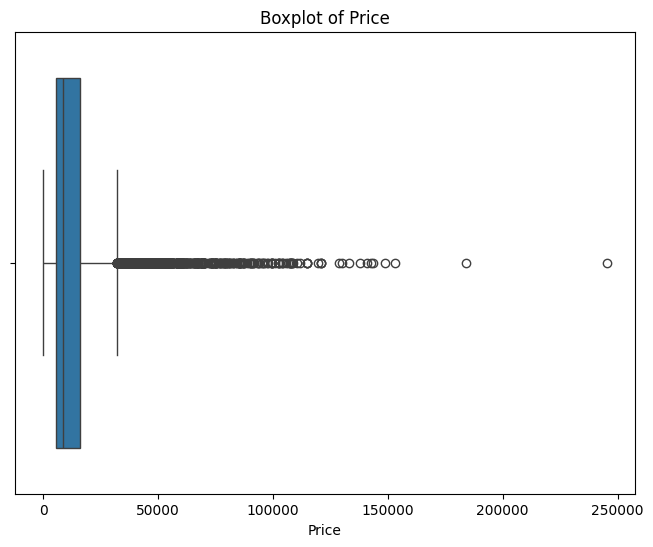

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df_raw['Price'])
plt.title('Boxplot of Price')
plt.show()

price 이상치 확인
박스플롯 그려봄

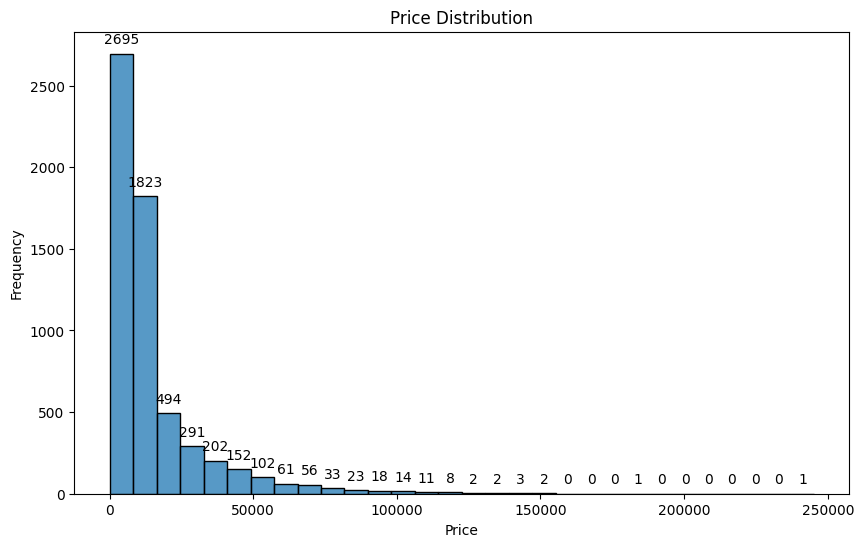

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df_raw['Price'], kde=False, bins=30)  # KDE를 끄고, bins는 막대의 수를 조절
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')

# 각 막대의 빈도수를 표시하는 코드
for rect in plt.gca().patches:
    plt.gca().annotate(f'{int(rect.get_height())}',
                       xy=(rect.get_x() + rect.get_width() / 2, rect.get_height()),
                       xytext=(0, 5),
                       textcoords='offset points',
                       ha='center',
                       va='bottom')

plt.show()


정규성을 띄지 않아 목표변수에 로그변환을 적용하여 분포 조정(로그변환을 통해 정규분포에 가깝게 만들기 가능)

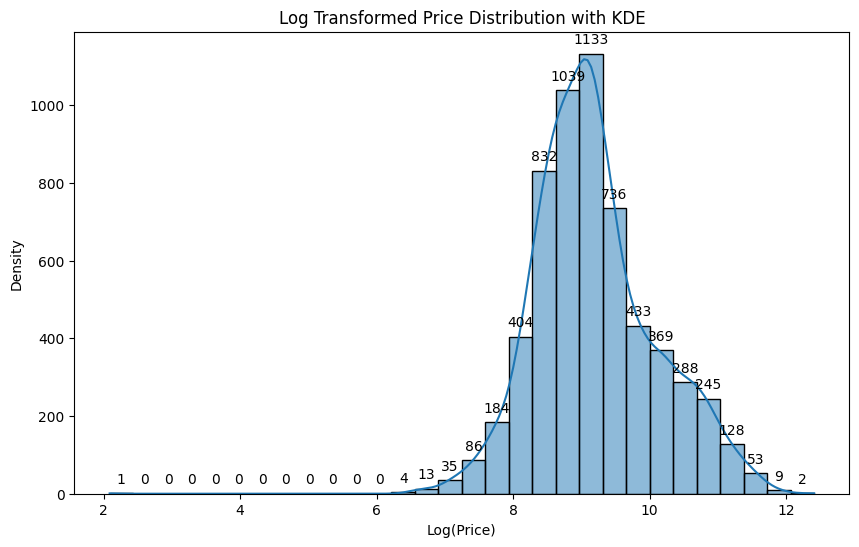

In [ ]:
import numpy as np

# Price 열에 로그 변환 후 새로운 열 추가
df_raw['log_price'] = np.log1p(df_raw['Price'])  # log1p는 1을 더한 후 로그 변환을 수행

plt.figure(figsize=(10, 6))
sns.histplot(df_raw['log_price'], kde=True, bins=30)  # 변환된 데이터에 대한 히스토그램 + KDE
plt.title('Log Transformed Price Distribution with KDE')
plt.xlabel('Log(Price)')
plt.ylabel('Density')

# 각 막대의 빈도수를 표시하는 코드
for rect in plt.gca().patches:
    plt.gca().annotate(f'{int(rect.get_height())}',
                       xy=(rect.get_x() + rect.get_width() / 2, rect.get_height()),
                       xytext=(0, 5),
                       textcoords='offset points',
                       ha='center',
                       va='bottom')

plt.show()


price 보다 price_log 가 정규성을 더 만족

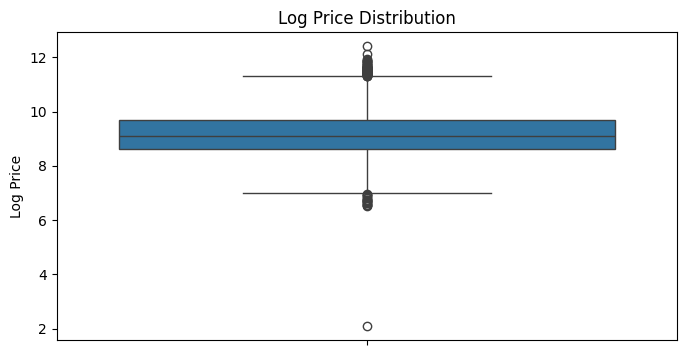

In [ ]:
# log_price에 대한 박스플롯 생성
plt.figure(figsize=(8, 4))  # 그래프 크기 설정
sns.boxplot(y=df_raw['log_price'])
plt.title('Log Price Distribution')  # 그래프 제목 설정
plt.ylabel('Log Price')  # y축 레이블 설정
plt.show()

price_log 최솟값 이상치 처리

In [ ]:
# price 극단치 데이터 처리

# 'log_price' 열에 대한 Q1과 Q3 계산
Q1 = df_raw['log_price'].quantile(0.25)
Q3 = df_raw['log_price'].quantile(0.75)
IQR = Q3 - Q1

# IQR을 사용하여 이상치가 아닌 데이터의 범위 정의
lower_bound = Q1 - 1.5 * IQR

df_raw= df_raw[df_raw['log_price'] >= lower_bound ]


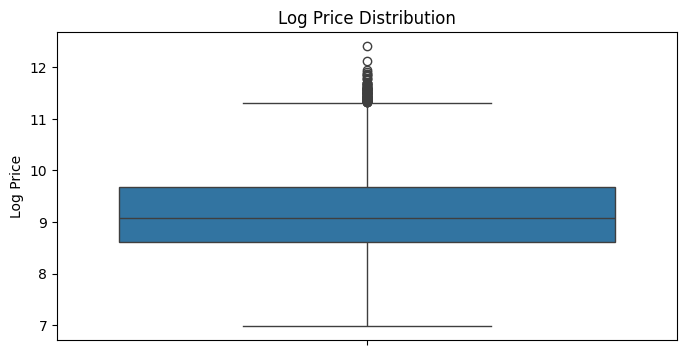

In [ ]:
# log_price에 대한 박스플롯 생성
plt.figure(figsize=(8, 4))  # 그래프 크기 설정
sns.boxplot(y=df_raw['log_price'])
plt.title('Log Price Distribution')  # 그래프 제목 설정
plt.ylabel('Log Price')  # y축 레이블 설정
plt.show()

# Fuel_Type변수 영향력

In [ ]:
# 1. Fuel_Type 변수의 분포 파악
# 주어진 DataFrame의 'Fuel_Type' 열의 값을 숫자로 변환하는 매핑 생성
fuel_type_mapping = {
    0 : 'Diesel',
    1 : 'Petrol',
    2 : 'CNG',
    3 : 'LPG'
}

# 'Fuel_Type' 열의 값을 위에서 생성한 매핑을 사용하여 숫자로 변환
df_raw['Fuel_Type_Code'] = df_raw['Fuel_Type'].map(fuel_type_mapping)

# 변환된 값 확인
print(df_raw['Fuel_Type_Code'].value_counts())

print(df_raw['Fuel_Type'].value_counts())

Diesel    3136
Petrol    2772
CNG         57
LPG         10
Name: Fuel_Type_Code, dtype: int64
0    3136
1    2772
2      57
3      10
Name: Fuel_Type, dtype: int64


Fuel_type바 차트 확인

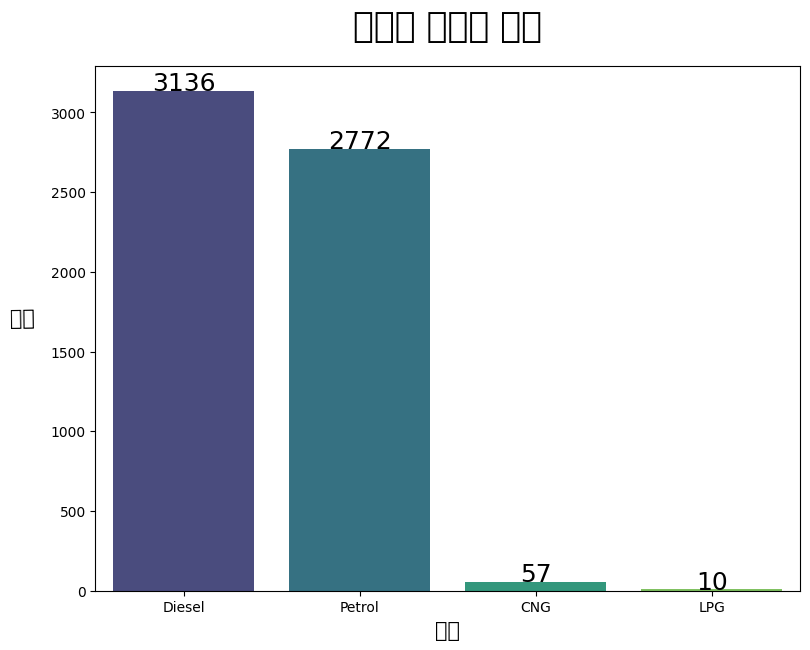

In [ ]:
# Fuel_Type 값 매핑
fuel_type_mapping = {0: 'Diesel', 1: 'Petrol', 2: 'CNG', 3: 'LPG'}
df_raw['Fuel_Type_mapped'] = df_raw['Fuel_Type'].replace(fuel_type_mapping)

plt.figure(figsize=(20,15))
plt.subplot(221)

g = sns.barplot(data=pd.DataFrame(df_raw['Fuel_Type_mapped'].value_counts()).T, palette='viridis', ci=False)

plt.title('연료별 중고차 분포', fontsize=25, y=1.04)
plt.xlabel('연료', fontsize=15)
plt.ylabel('수량', fontsize=15, rotation=1, labelpad=20)

for i in range(len(df_raw['Fuel_Type_mapped'].value_counts())):
    g.text(i, df_raw['Fuel_Type_mapped'].value_counts()[i], df_raw['Fuel_Type_mapped'].value_counts()[i],
    color='black', ha='center', fontsize=18)

plt.show()


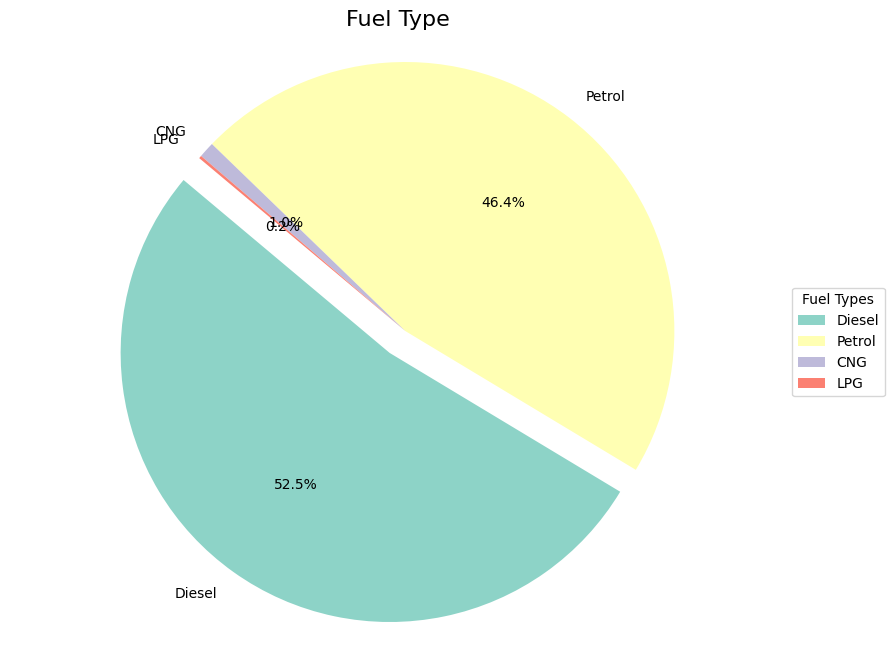

In [ ]:
# 연료 유형에 대한 매핑
fuel_type_mapping = {
    0: 'Diesel',
    1: 'Petrol',
    2: 'CNG',
    3: 'LPG'
}

# 'Fuel_Type'의 값별 개수를 계산
fuel_type_counts = df_raw['Fuel_Type'].value_counts()

# 'Fuel_Type'의 값별 개수를 계산하고, 큰 순서대로 정렬
fuel_type_counts = df_raw['Fuel_Type'].value_counts().sort_values(ascending=False)

# 각 조각에 대한 'explode' 설정: 가장 큰 조각을 강조
explode = [0.1 if i == 0 else 0 for i in range(len(fuel_type_counts))]

# 파이 차트 시각화
plt.figure(figsize=(10, 8))  # 차트의 크기 설정
plt.pie(fuel_type_counts, labels=[fuel_type_mapping[i] for i in fuel_type_counts.index], autopct='%1.1f%%', startangle=140, colors=sns.color_palette("Set3", len(fuel_type_counts)), explode=explode)
plt.title('Fuel Type', fontsize=16)  # 차트 제목 설정
plt.axis('equal')  # 차트를 원형으로 만듭니다

# 범례 추가
plt.legend([fuel_type_mapping[i] for i in fuel_type_counts.index], title="Fuel Types", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.show()


Diesel, Petrol, CNG, LPG순으로 판매량 순위가 매겨진다.

log_price와 Fuel_Type간 비교

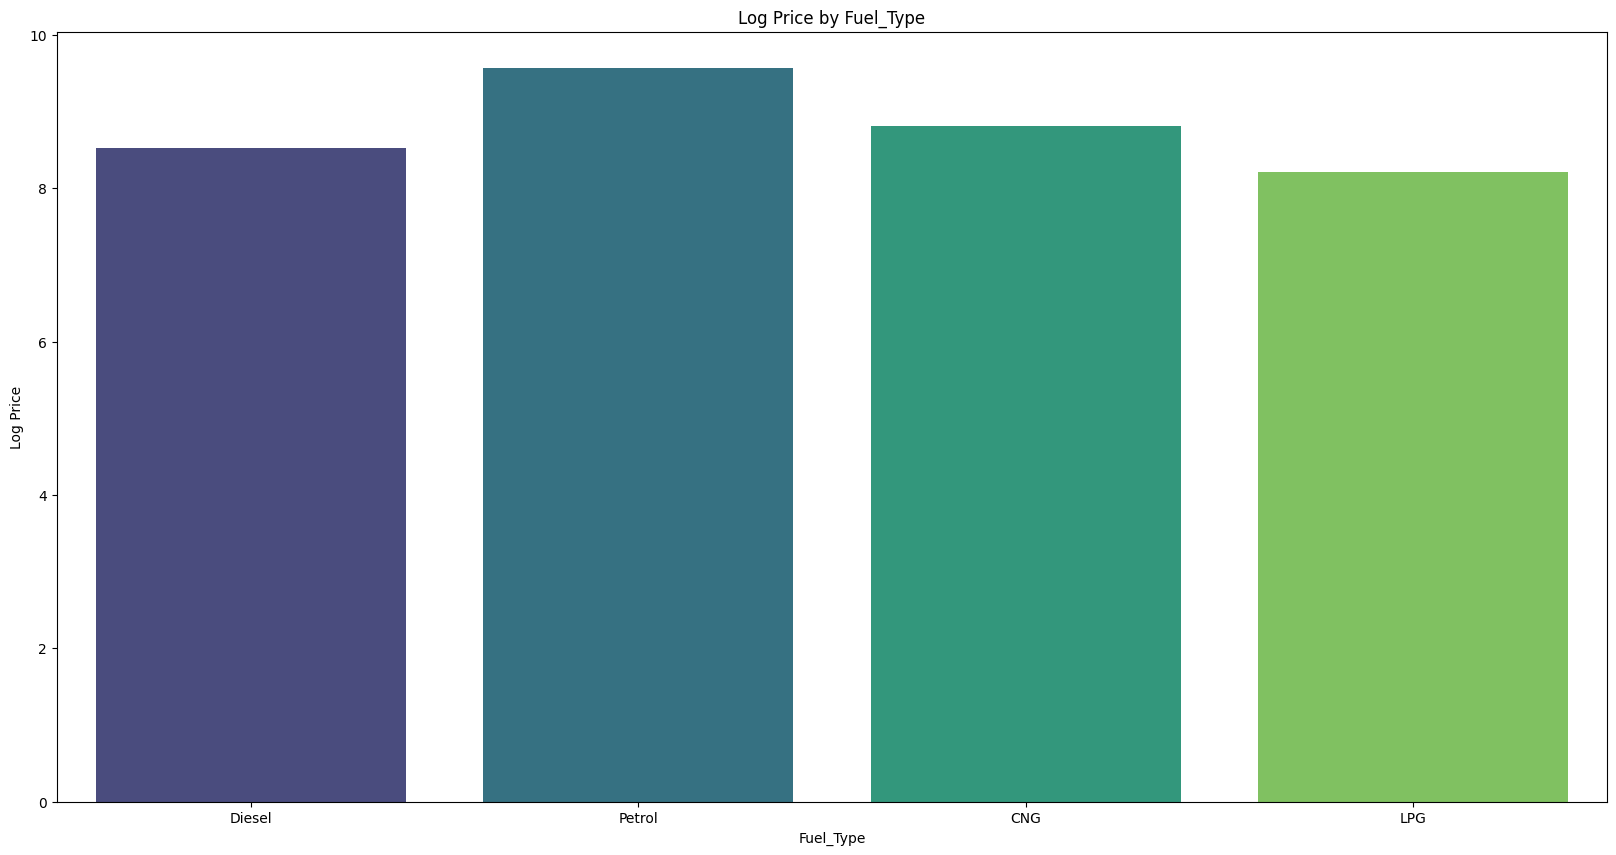

In [ ]:
# Fuel_Type 값 매핑
fuel_type_mapping = {0: 'Diesel', 1: 'Petrol', 2: 'CNG', 3: 'LPG'}
df_raw['Fuel_Type_mapped'] = df_raw['Fuel_Type'].replace(fuel_type_mapping)

plt.figure(figsize=(20,10))
sns.barplot(
    data=df_raw,
    x='Fuel_Type_mapped',
    y='log_price',
    palette='viridis', ci=False
)
plt.xlabel('Fuel_Type')
plt.ylabel('Log Price')
plt.title('Log Price by Fuel_Type')
plt.xticks(ticks=[0, 1, 2, 3], labels=['Diesel', 'Petrol', 'CNG', 'LPG'])  # x축 레이블 수정
plt.show()


# 변속기별 중고차 분포(Transmission)


In [ ]:
df_raw['Transmission'].isnull().sum()

0

In [ ]:
df_raw['Transmission'].unique()

array([1, 2])

In [ ]:
df_raw['Transmission'].value_counts()

1    4216
2    1759
Name: Transmission, dtype: int64

transmission 바차트 확인

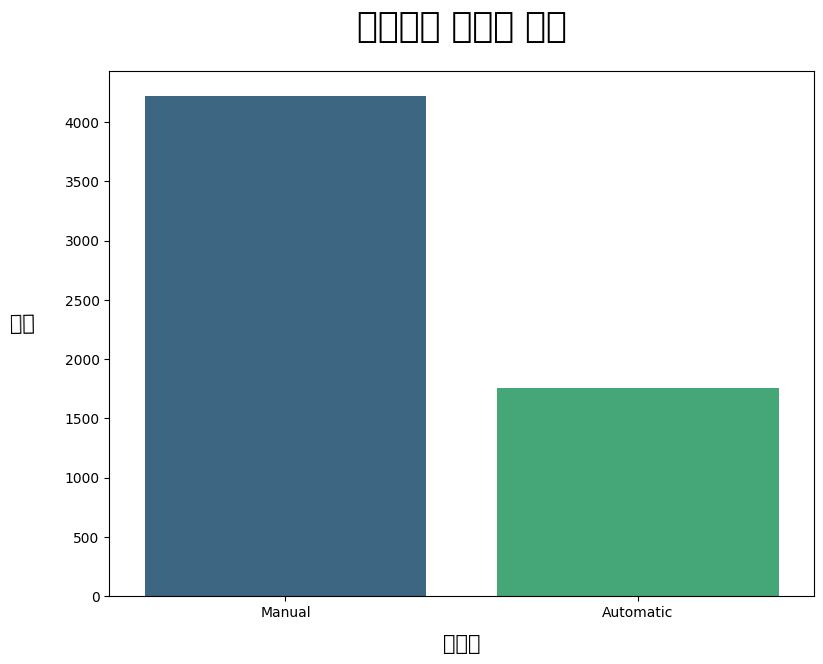

In [ ]:
# 변속기 유형에 대한 매핑
transmission_mapping = {
    1: 'Manual',
    2: 'Automatic'
}

plt.figure(figsize=(20,15))
plt.subplot(221)

# 'Transmission' 열의 값별 개수를 계산하고, 매핑을 사용하여 값을 변경한 후 시각화합니다.
transmission_counts = df_raw['Transmission'].replace(transmission_mapping).value_counts().sort_index(ascending=False)
sns.barplot(x=transmission_counts.index, y=transmission_counts, palette='viridis', ci=False)

plt.title('변속기별 중고차 분포', fontsize=25, y=1.05)
plt.xlabel('변속기', fontsize=15, labelpad=10)
plt.ylabel('수량', fontsize=15, rotation=1, labelpad=30)

plt.show()


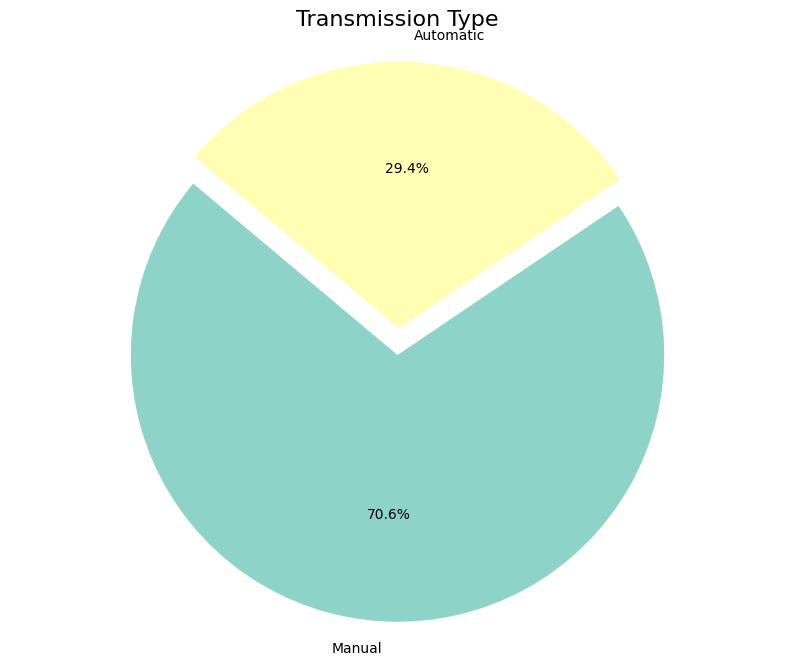

In [ ]:
# Transmission 값 매핑
transmission_mapping = {1: 'Manual', 2: 'Automatic'}

# 'Transmission'의 값별 개수를 계산하고, 큰 순서대로 정렬
transmission_counts = df_raw['Transmission'].value_counts().sort_values(ascending=False)

# 각 조각에 대한 'explode' 설정: 가장 큰 조각을 강조
explode = [0.1 if i == 0 else 0 for i in range(len(transmission_counts))]

# 파이 차트 시각화
plt.figure(figsize=(10, 8))  # 차트의 크기 설정
plt.pie(transmission_counts, labels=[transmission_mapping.get(i, i) for i in transmission_counts.index], autopct='%1.1f%%', startangle=140, colors=sns.color_palette("Set3", len(transmission_counts)), explode=explode)
plt.title('Transmission Type', fontsize=16)  # 차트 제목 설정
plt.axis('equal')  # 차트를 원형으로 만듭니다

plt.show()


log_price 와 transmission 비교

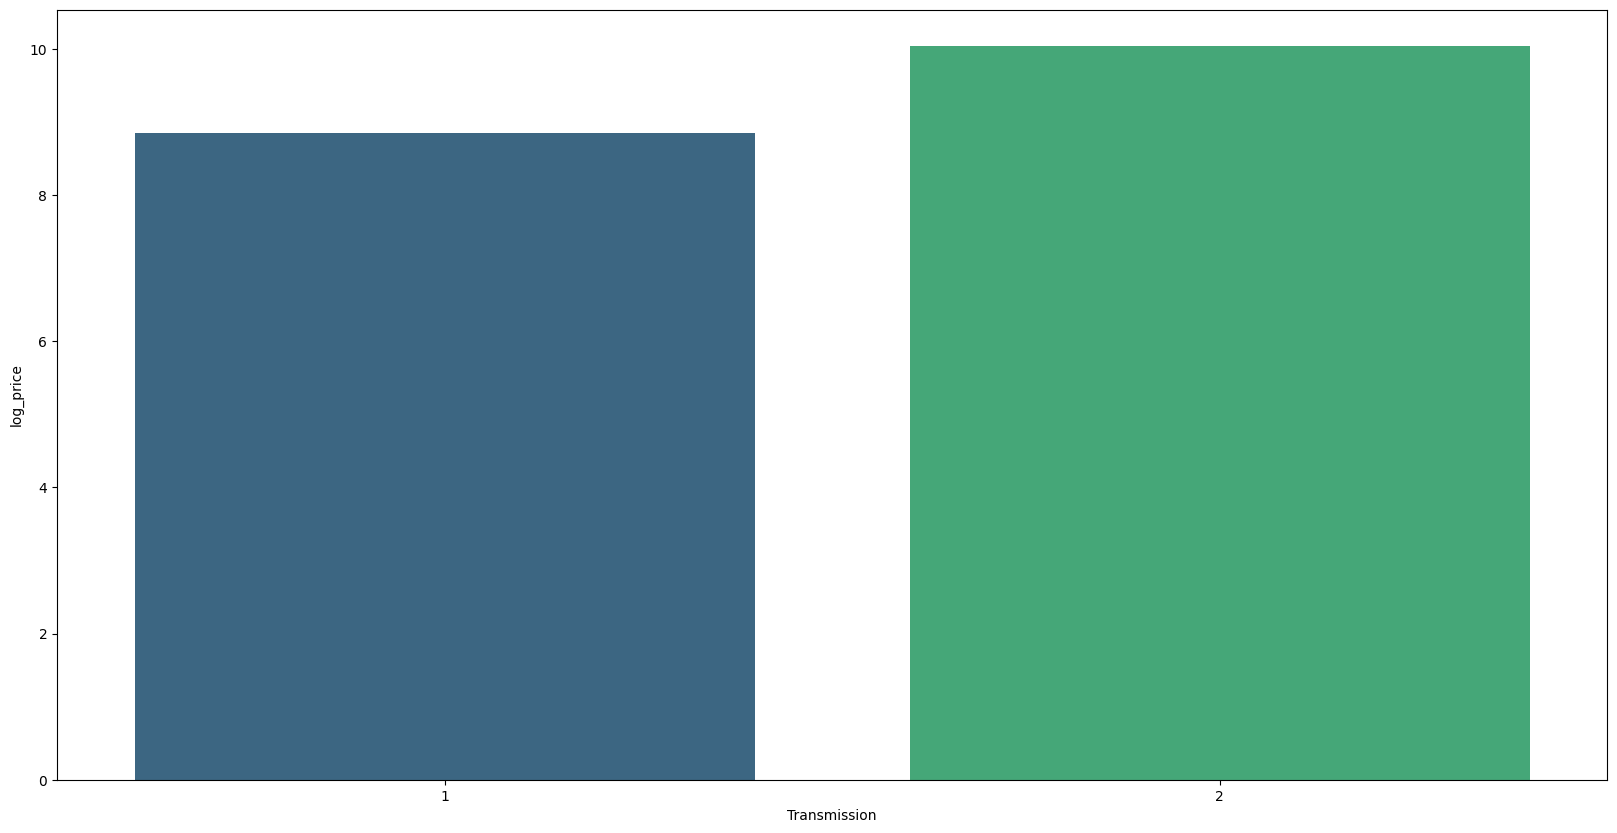

In [ ]:
transmission_mapping = {
    1: 'Manual',
    2: 'Automatic'
}

plt.figure(figsize=(20,10))
sns.barplot(
    data= df_raw,
    x= "Transmission",
    y= "log_price",
    palette='viridis', ci=False
)
plt.show()

In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5975 entries, 0 to 5992
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Price              5975 non-null   float64
 1   Kilometers_Driven  5975 non-null   int64  
 2   Fuel_Type          5975 non-null   int64  
 3   Transmission       5975 non-null   int64  
 4   Owner_Type         5975 non-null   int64  
 5   Mileage            5975 non-null   float64
 6   Engine             5975 non-null   float64
 7   Power              5975 non-null   float64
 8   Seats              5975 non-null   float64
 9   Brand              5975 non-null   int64  
 10  Vehicle_Age        5975 non-null   int64  
 11  Brand_Group        5975 non-null   int64  
 12  city_location      5975 non-null   int64  
 13  log_price          5975 non-null   float64
 14  Fuel_Type_Code     5975 non-null   object 
 15  Fuel_Type_mapped   5975 non-null   object 
dtypes: float64(6), int64(8),

# 카이제곱 검정

In [ ]:
df_raw['Fuel_Type'].unique()

array([2, 0, 1, 3])

In [ ]:
from scipy import stats

# Fuel_Type에 따라 Price_log를 그룹화
grouped_data = [df_raw[df_raw['Fuel_Type'] == i]['log_price'] for i in range(4)]

# 정규성 검정 (Shapiro-Wilk test)
shapiro_results = []
fuel_types = ['Diesel', 'Petrol', 'CNG', 'LPG']
for fuel, data in zip(fuel_types, grouped_data):
    shapiro_result = stats.shapiro(data)
    shapiro_results.append((fuel, shapiro_result))
print("\nShapiro-Wilk Test for Normality:")
for fuel, result in shapiro_results:
    print(f"Fuel Type: {fuel}, p-value: {result.pvalue}")
# 등분산성 검정 (Levene's test)
levene_test = stats.levene(*grouped_data)
print("Levene's Test for Homogeneity of Variance:")
print(levene_test)



# 독립성 확인
# 독립성은 특별한 검정이 필요하지 않습니다. 자료가 무작위로 선택되었거나 실험이 독립적으로 수행되었다면 독립성을 만족합니다.



Shapiro-Wilk Test for Normality:
Fuel Type: Diesel, p-value: 1.1263238636379297e-18
Fuel Type: Petrol, p-value: 6.3165993835828e-24
Fuel Type: CNG, p-value: 0.11184567958116531
Fuel Type: LPG, p-value: 0.1741962730884552
Levene's Test for Homogeneity of Variance:
LeveneResult(statistic=58.13141824201747, pvalue=4.923001461313662e-37)


정규성을 만족하지 않는다

In [ ]:
from scipy.stats import kruskal

# Fuel_Type에 따른 Price_log 값을 저장합니다.
price_diesel = df_raw[df_raw['Fuel_Type'] == 0]['log_price']
price_petrol = df_raw[df_raw['Fuel_Type'] == 1]['log_price']
price_cng = df_raw[df_raw['Fuel_Type'] == 2]['log_price']
price_lpg = df_raw[df_raw['Fuel_Type'] == 3]['log_price']

# Kruskal-Wallis H 검정을 수행합니다.
statistic, p_value = kruskal(price_diesel, price_petrol, price_cng, price_lpg)
print("Kruskal-Wallis H test p-value:", p_value)

if p_value < 0.05:
    print("Fuel_Type과 Price_log 간의 차이는 통계적으로 유의미합니다.")
else:
    print("Fuel_Type과 Price_log 간의 차이는 통계적으로 유의미하지 않습니다.")


Kruskal-Wallis H test p-value: 1.2068835994163206e-269
Fuel_Type과 Price_log 간의 차이는 통계적으로 유의미합니다.


In [ ]:
import scipy.stats as stats
import seaborn as sns

# Transmission 값 변환
df_raw['Transmission'] = df_raw['Transmission'].replace({1: 'Manual', 2: 'Automatic'})

# 정규성 검정
stat, p_value = stats.shapiro(df_raw['log_price'])
print("Shapiro-Wilk test p-value:", p_value)
# 등분산성 검정
manual = df_raw[df_raw['Transmission'] == 'Manual']['log_price']
automatic = df_raw[df_raw['Transmission'] == 'Automatic']['log_price']

stat, p_value = stats.levene(manual, automatic)
print("Levene's test p-value:", p_value)





Shapiro-Wilk test p-value: 3.724065710094318e-29
Levene's test p-value: 4.442651257518484e-67


In [ ]:
df_raw['Transmission'] = df_raw['Transmission'].map({'Manual': 1, 'Automatic': 2})


In [ ]:
from scipy.stats import mannwhitneyu

# Transmission이 Manual인 경우와 Automatic인 경우로 데이터를 나눕니다.
price_manual = df_raw[df_raw['Transmission'] == 1]['log_price']
price_automatic = df_raw[df_raw['Transmission'] == 2]['log_price']

# Mann-Whitney U test를 수행합니다.
statistic, p_value = mannwhitneyu(price_manual, price_automatic)
print("Mann-Whitney U test p-value:", p_value)

if p_value < 0.05:
    print("Transmission과 Price_log 간의 차이는 통계적으로 유의미합니다.")
else:
    print("Transmission과 Price_log 간의 차이는 통계적으로 유의미하지 않습니다.")


Mann-Whitney U test p-value: 0.0
Transmission과 Price_log 간의 차이는 통계적으로 유의미합니다.


정규성 검정에서 정규성을 만족하지 않아서 비모수적 방법중 mannwhitney를 돌린 결과 유의미하다고 판단